In [26]:
import numpy as np
print('numpy: %s' % np.__version__) # print version

# Note need to 'pip install gym', and 'pip install gym[toy_text]'
                                 # or 'pip install gym\[toy_text\]' if zsh does nor recongize the first command
import gymnasium as gym # for simulated environments
print('gym: %s' % gym.__version__) # print version

import matplotlib
import matplotlib.pyplot as plt # for displaying environment states
print('matplotlib: %s' % matplotlib.__version__) # print version

from IPython import display # for displaying environment states
import time # for slowing down rendering of states by adding small time delays

numpy: 2.1.3
gym: 1.3.0
matplotlib: 3.10.0


In [15]:
# Setup environment
env = gym.make(id='FrozenLake-v1', # choose one of the existing environments
               desc=None, # Used to specify custom map for frozen lake. E.g., desc=["SFFF", "FHFH", "FFFH", "HFFG"].
               map_name='4x4', # ID to use any of the preloaded maps. E.g., '4x4', '8x8'
               is_slippery=False, # True/False. If True will move in intended direction with probability of 1/3 else will move in either perpendicular direction with equal probability of 1/3 in both directions.
               max_episode_steps=None, # default=None, Maximum length of an episode (TimeLimit wrapper).
               disable_env_checker=None, # default=None, If to run the env checker
               render_mode = 'rgb_array' # The set of supported modes varies per environment. (And some third-party environments may not support rendering at all.)
              )

In [20]:
env.unwrapped.desc

array([[b'S', b'F', b'F', b'F'],
       [b'F', b'H', b'F', b'H'],
       [b'F', b'F', b'F', b'H'],
       [b'H', b'F', b'F', b'G']], dtype='|S1')

In [21]:
# Observation and action space
state_obs_space = env.observation_space # Returns sate(observation) space of the environment.
action_space = env.action_space # Returns action space of the environment.
print("State(Observation) space:", state_obs_space)
print("Action space:", action_space)

State(Observation) space: Discrete(16)
Action space: Discrete(4)


In [24]:
# Specify seed for reproducability (optional)
env.action_space.seed(42)

# Reset environment to initial state
state, info = env.reset(seed=42)

# Print the state(observstion) of the environment
print("The initial state is {}".format(state))
print("The initial information {}".format(info))

The initial state is 0
The initial information {'prob': 1}


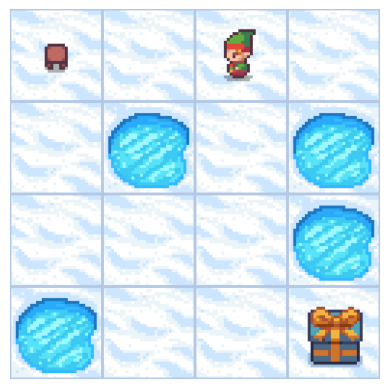

In [36]:
# Cycle through 20 random steps redering and displaying the agent inside the environment each time
for _ in range(20):

    # Render and display current state of the environment
    plt.imshow(env.render()) # render current state and pass to pyplot
    plt.axis('off')
    display.display(plt.gcf()) # get current figure and display
    display.clear_output(wait=True) # clear output before showing the next frame

    # Sample a random action from the entire action space
    random_action = env.action_space.sample()

    # Pass the random action into the step function
    state, reward, done, _, info = env.step(random_action)

    # Wait a little bit before the next frame
    time.sleep(0.2)

    # Reset environment when done=True, i.e., when the agent falls into a Hole (H) or reaches the Goal (G)
    if done:
        # Render and display current state of the environment
        plt.imshow(env.render()) # render current state and pass to pyplot
        plt.axis('off')
        display.display(plt.gcf()) # get current figure and display
        display.clear_output(wait=True) # clear output before showing the next frame
        # Reset environment
        state, info = env.reset()

# Close environment
env.close()

In [28]:
# Q-function parameters
alpha = 0.7   # learning rate
gamma = 0.95  # discount factor

# Training parameters
n_episodes = 10000  # number of episodes to use for training
n_max_steps = 100   # maximum number of steps per episode

# Exploration / Exploitation parameters
start_epsilon = 1.0  # start training by selecting purely random actions
min_epsilon = 0.05   # the lowest epsilon allowed to decay to
decay_rate = 0.001   # epsilon will gradually decay so we do less exploring and more exploiting as Q-function improves

In [29]:
# Initial Q-table
# Our Q-table is a matrix of state(observation) space x action space, i.e., 16 x 4
Qtable = np.zeros((env.observation_space.n, env.action_space.n))

# Show
Qtable

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [30]:
# This is our acting policy (epsilon-greedy), for the agent to do exploration and exploitation during training
def epsilon_greedy(Qtable, state, epsilon):
    # Generate a random number and compare to epsilon, if lower then explore, itherwuse exploit
    randnum = np.random.uniform(0, 1)
    if randnum < epsilon:
        action = env.action_space.sample()    # explore
    else:
        action = np.argmax(Qtable[state, :])  # exploit
    return action

In [31]:
# This is our updating policy (greedy)
# i.e., always select the action with the highest value for that state: np.max(Qtable[next_state])
def update_Q(Qtable, state, action, reward, next_state):
    # Q(S_t,A_t) = Q(S_t,A_t) + alpha [R_t+1 + gamma * max Q(S_t+1,a) - Q(S_t,A_t)]
    Qtable[state][action] = Qtable[state][action] + alpha * (reward + gamma * np.max(Qtable[next_state]) - Qtable[state][action])
    return Qtable

In [32]:
# Always go for the highest value (state,action) pair
def eval_greedy(Qtable, state):
    action = np.argmax(Qtable[state, :])
    return action

In [34]:
def train(n_episodes, n_max_steps, start_epsilon, min_epsilon, decay_rate, Qtable):
    for episode in range(n_episodes):

        # Reset the environment at the start of each episode
        state, info = env.reset()
        t = 0
        done = False

        # Calculate epsilon value based on decay rate
        epsilon = max(min_epsilon, (start_epsilon - min_epsilon)*np.exp(-decay_rate*episode))

        for t in range(n_max_steps):
            # Choose an action using previously defined epsilon greedy policy
            action = epsilon_greedy(Qtable, state, epsilon)

            # Perform the action in the environment, get reward and next state
            next_state, reward, done, _, info = env.step(action)

            # Update Q-table
            Qtable = update_Q(Qtable, state, action, reward, next_state)

            # Update current state
            state = next_state

            # Finish the episode when done=True, i.e., reached the goal or fallen into a hole
            if done:
                break

    # Return final Q-table
    return Qtable

In [35]:
# Train
Qtable = train(n_episodes, n_max_steps, start_epsilon, min_epsilon, decay_rate, Qtable)

# Show Q-table
Qtable

array([[0.73509189, 0.77378094, 0.77378094, 0.73509189],
       [0.73509189, 0.        , 0.81450625, 0.77378094],
       [0.77378094, 0.857375  , 0.77378094, 0.81450625],
       [0.81450625, 0.        , 0.7737809 , 0.7737809 ],
       [0.77378094, 0.81450625, 0.        , 0.73509189],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.9025    , 0.        , 0.81450625],
       [0.        , 0.        , 0.        , 0.        ],
       [0.81450625, 0.        , 0.857375  , 0.77378094],
       [0.81450625, 0.9025    , 0.9025    , 0.        ],
       [0.857375  , 0.95      , 0.        , 0.857375  ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.9025    , 0.95      , 0.857375  ],
       [0.9025    , 0.95      , 1.        , 0.9025    ],
       [0.        , 0.        , 0.        , 0.        ]])

In [37]:
def evaluate_agent(n_max_steps, n_eval_episodes, Qtable):
    # Initialize an empty list to store rewards for each episode
    episode_rewards=[]

    # Evaluate for each episode
    for episode in range(n_eval_episodes):

        # Reset the environment at the start of each episode
        state, info = env.reset()
        t = 0
        done = False
        tot_episode_reward = 0

        for t in range(n_max_steps):

            # Use greedy policy to evaluate
            action = eval_greedy(Qtable, state)

            # Pass action into step function
            next_state, reward, done, _, info = env.step(action)

            # Sum episode rewards
            tot_episode_reward += reward

            # Update current state
            state = next_state

            # Finish the episode when done=True, i.e., reached the goal or fallen into a hole
            if done:
                break

        episode_rewards.append(tot_episode_reward)

    mean_reward = np.mean(episode_rewards)
    std_reward = np.std(episode_rewards)

    return mean_reward, std_reward

In [38]:
n_eval_episodes=100
mean_reward, std_reward = evaluate_agent(n_max_steps, n_eval_episodes, Qtable)
print(f"Mean Reward = {mean_reward:.2f} +/- {std_reward:.2f}")

Mean Reward = 1.00 +/- 0.00


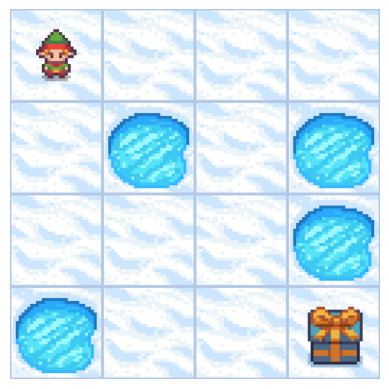

In [39]:
# Cycle through 19 steps redering and displaying environment state each time
state, info = env.reset()
for _ in range(19):

    # Render and display current state of the environment
    plt.imshow(env.render()) # render current state and pass to pyplot
    plt.axis('off')
    display.display(plt.gcf()) # get current figure and display
    display.clear_output(wait=True) # clear output before showing the next frame

    # Use greedy policy to evaluate
    action = eval_greedy(Qtable, state)

    # Pass action into step function
    state, reward, done, _, info = env.step(action)

    # Wait a little bit before the next frame
    time.sleep(0.2)

    # Reset environment when done=True, i.e. when the agent falls into a Hole (H) or reaches the Goal (G)
    if done:
        # Render and display final state of the environment
        plt.imshow(env.render()) # render current state and pass to pyplot
        plt.axis('off')
        display.display(plt.gcf()) # get current figure and display
        display.clear_output(wait=True) # clear output before showing the next frame
        state, info = env.reset()

env.close()